# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [9]:
# Import essential libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import keras
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from sklearn.utils import shuffle

Load the dataset.

In [10]:
# Load and unzip the dataset

import zipfile
import os

zip_filename = '/content/data.zip'
folder_path ='/content/'

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(folder_path)


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [11]:
# Create a function to load the raw images

def load_images(root_dir, allowed_ext={'.jpg', '.jpeg', '.png'}):
    images = []
    labels = []

    class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_index = {name: indx for indx, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)

        for fname in os.listdir(class_dir):
            ext = os.path.splitext(fname)[-1].lower()

            if ext in allowed_ext:
                img_path = os.path.join(class_dir, fname)

                try:
                    img = Image.open(img_path).convert('RGB')
                    img_array = np.array(img)
                    images.append(img_array)
                    labels.append(class_index[class_name])

                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")

    return images, labels, class_names

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [12]:
# Get the images and their labels

dataset_path='/content/data'

images, labels, class_names = load_images(dataset_path)

print(f"Loaded {len(images)} images.")
print(f"No of labels: {len(labels)}")
print("Classes:", class_names)



Loaded 7625 images.
No of labels: 7625
Classes: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

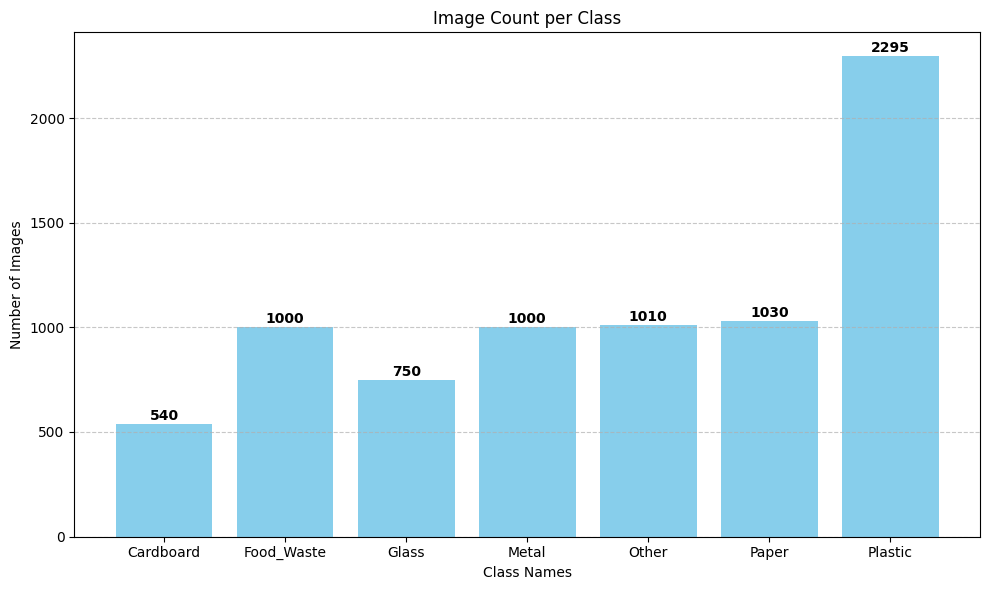

In [13]:
# Visualise Data Distribution

label_counts = Counter(labels)
label_names = [class_names[i] for i in label_counts.keys()]
label_values = [label_counts[i] for i in label_counts.keys()]

plt.figure(figsize=(10, 6))
bars=plt.bar(label_names, label_values, color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
plt.xlabel('Class Names')
plt.ylabel('Number of Images')
plt.title('Image Count per Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

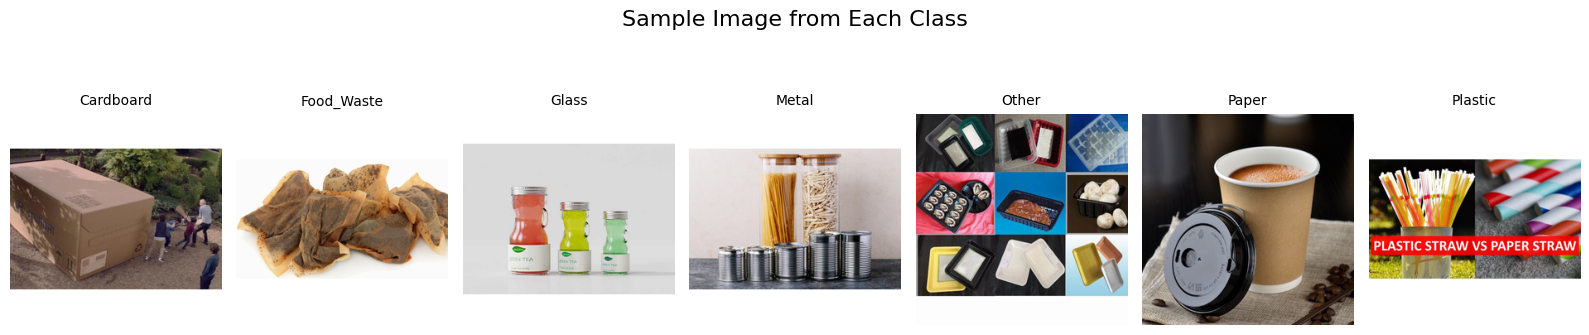

In [14]:
# Visualise Sample Images (across different labels)

plt.figure(figsize=(16, 4))

for i, class_name in enumerate(np.unique(labels)):

    idx = np.where(labels == class_name)[0][0]

    image = images[idx]

    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(image.astype("uint8"))
    plt.title(class_names[class_name], fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Image from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [15]:
# Find the smallest and largest image dimensions from the data set
image_shapes = [img.shape[:2] for img in images]
image_shapes = np.array(image_shapes)

min_height, min_width = image_shapes.min(axis=0)
max_height, max_width = image_shapes.max(axis=0)

print(f"Smallest image dimensions: {min_width} x {min_height}")
print(f"Largest image dimensions: {max_width} x {max_height}")


Smallest image dimensions: 256 x 256
Largest image dimensions: 256 x 256


In [16]:
# Resize the image dimensions

#all image dimensions are 256x256. Resizing image dimensions to 128x128
target_size = (128, 128)
resized_images = []

for img in images:
    pil_img = Image.fromarray(img)
    resized_img = pil_img.resize(target_size, Image.BILINEAR)
    resized_images.append(np.array(resized_img))

resized_images = np.array(resized_images)

print(f"All images resized to: {resized_images.shape[1]} x {resized_images.shape[2]}")


All images resized to: 128 x 128


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [17]:
# Encode the labels suitably

encoded_labels = tf.keras.utils.to_categorical(labels, len(class_names))
encoded_labels.shape


(7625, 7)

### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [27]:
# Assign specified parts of the dataset to train and validation sets

#60% training, 20% validation, 20% test

X_train, X_temp, y_train, y_temp= train_test_split(resized_images,encoded_labels, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f'Training dataset size:{len(X_train)}')
print(f'Testing dataset size:{len(X_test)}')
print(f'Validation dataset size:{len(X_val)}')

X_train = X_train/255.0
X_val = X_val/255.0
X_test = X_test/255.0

Training dataset size:4575
Testing dataset size:1525
Validation dataset size:1525


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [33]:
# Build and compile the model

input_shape = (128, 128, 3)
num_classes = 7

model = models.Sequential([
    #1st convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #2nd convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #3rd convolutional layer
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,496,135 (17.15 MB)

 Trainable params: 4,495,111 (17.15 MB)

 Non-trainable params: 1,024 (4.00 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [34]:
# Training

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 161ms/step - accuracy: 0.2245 - loss: 2.3314 - val_accuracy: 0.2164 - val_loss: 2.8908 - learning_rate: 0.0010
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.3678 - loss: 1.7810 - val_accuracy: 0.2859 - val_loss: 4.5620 - learning_rate: 0.0010
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4004 - loss: 1.7048 - val_accuracy: 0.2833 - val_loss: 7.2251 - learning_rate: 0.0010
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4507 - loss: 1.5239 - val_accuracy: 0.2210 - val_loss: 2.2505 - learning_rate: 0.0010
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.4762 - loss: 1.4295 - val_accuracy: 0.4013 - val_loss: 1.6610 - learning_rate: 0.0010
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5489 - loss: 1.2681 - val_accuracy: 0.3495 - val_loss: 2.0360 - learning_rate: 0.0010
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5638 - lo

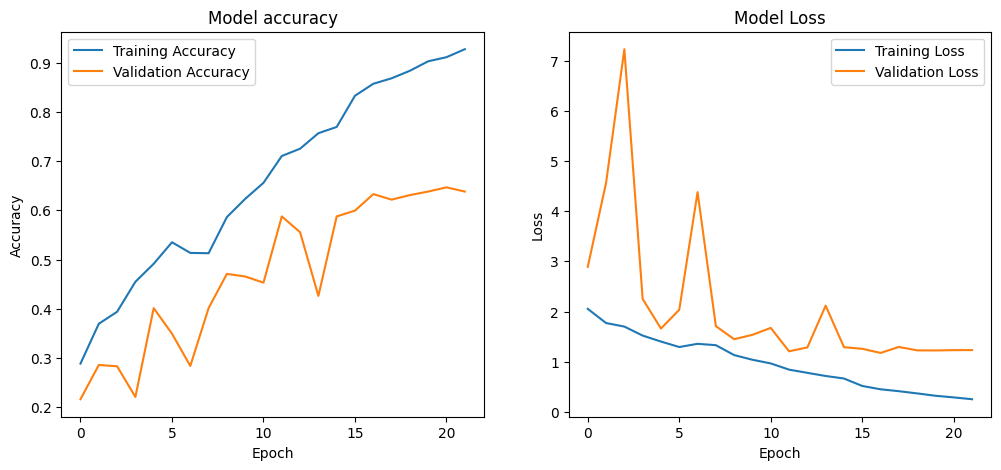

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss','Validation Loss'])
plt.show()

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

48/48 - 1s - 15ms/step - accuracy: 0.6203 - loss: 1.2463
Test Accuracy: 0.6203
Test Loss: 1.2463
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step

Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.73      0.75      0.74       114
  Food_Waste       0.63      0.69      0.66       184
       Glass       0.48      0.66      0.55       151
       Metal       0.66      0.50      0.57       199
       Other       0.48      0.50      0.49       199
       Paper       0.64      0.45      0.53       212
     Plastic       0.69      0.73      0.71       466

    accuracy                           0.62      1525
   macro avg       0.62      0.61      0.61      1525
weighted avg       0.63      0.62      0.62      1525



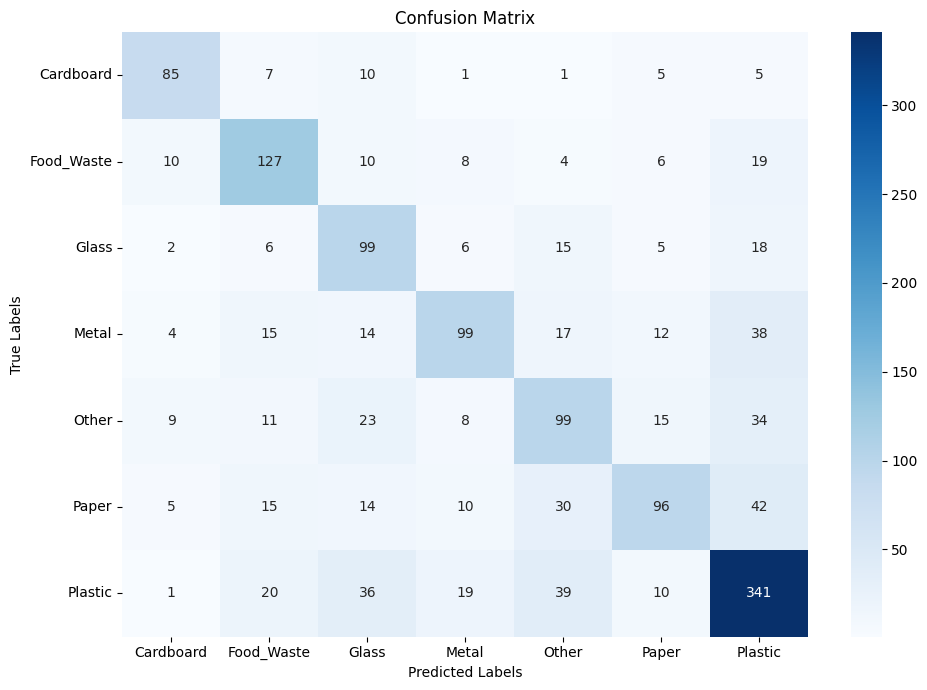

In [36]:
# Evaluate on the test set; display suitable metrics

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")



y_true = np.argmax(y_test, axis=1)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images



In [ ]:
# Create the augmented training dataset



In [ ]:
# Visualise Data Distribution



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images


## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

**1. Findings about the Data:**
- The dataset contains 7625 images with dimension 256x256 for all 7 waste categories(Cardboard, Food_Waste, Glass, Metal, Other, Paper, Plastic).
- Class imbalance found from bar plot visualisation of the data.
- Plastic Class has highest number of images 2295(Majority Class) and Craboard has lowest number of images 540(Minority Class).
- All images resized to 128x128 to improve computational efficiency.
- Dataset was split into 60% training set, 20% validation set and 20% test set
- - Training dataset contains 4575 images.
- - Testing dataset contains 1525 images.
- - Validation dataset contains 1525 images.

**2. Model Architecture Summary:**

- Convolutional Neural Network(CNN) Model was developed using TensorFlow’s Keras Sequential API.
- The model takes 128×128x3 RGB images as input and predicts one of 7 waste categories.
- It includes 3 convolutional layers with 128 filters each, followed by batch normalization, max pooling, and dropout(0.25) to reduce overfitting.
- After flattening the output, it passes through a dense(fully connected) layer with 128 units and a dropout of 0.5, before the final output layer with softmax activation.
- The total number of trainable parameters is approximately 4.49 million.
- Regularization techniques like Batch Normalization and Dropout are used to improve model generalization.

**3. Model Training Results:**

- Training Accuracy is 92.39% (Training Loss: 0.2581)
- Validation Accuracy is 63.8% (Validation Loss: 1.2326)
- Test Accuracy is 62.03% (Test Loss: 1.2463)
- The gap between training and validation/test accuracy suggests overfitting.
- Learning Rate Scheduler (ReduceLROnPlateau) effectively controlled learning when plateaus were detected.
- The model achieved an overall test accuracy of 62% on a dataset of 1525 test images.
- Precision, recall, and F1-scores vary across classes, indicating the model performs better on certain categories (like Plastic and Cardboard) compared to others (like Other and Paper)